This is an attempt to drastically speed up the drizzle-like approach from [single_forward_model4_build2d.ipynb](single_forward_model4_build2d.ipynb) using Nvidia Numba custom kernels, following the struggles of regular JAX in [jax_build2d.ipynb](jax_build2d.ipynb).  Note, all data are fake but of comparable dimension.

In [109]:
import math

from matplotlib import pyplot as plt

import numpy as np
from numba import cuda
import cupy as cp

# Mock data

Make fake "data" of a dimensionality that's not crazy, and populate it with some random nans

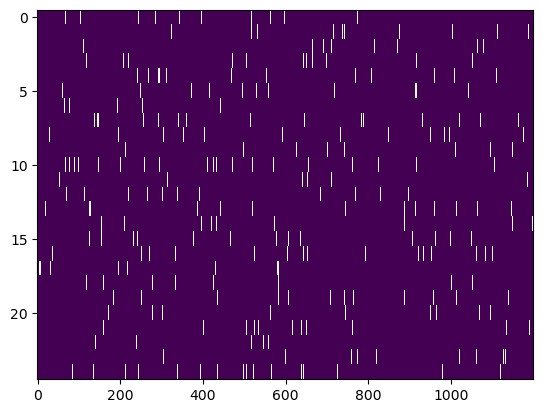

In [2]:
slit = np.zeros((25, 1200))

nanmsk = np.random.uniform(size=slit.shape)>.98

slit[nanmsk] = np.nan*slit[nanmsk]

plt.imshow(slit,aspect='auto', interpolation='nearest')

Make a fake spectrum that's somewhat denser than the "data"

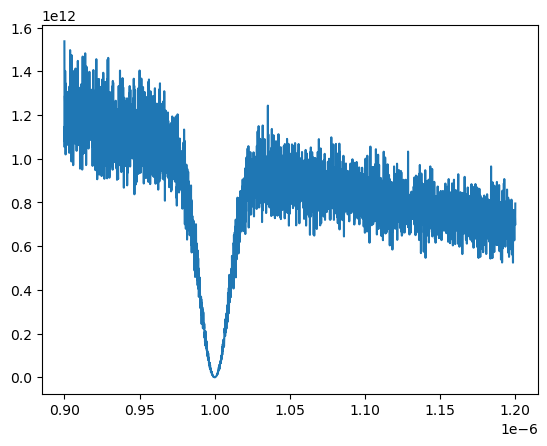

In [3]:
wave_m = np.linspace(0.9e-6, 1.2e-6, 4096)
spectrum = np.ones_like(wave_m)

# this spectrum is artificially noisy with a single bit aborption line.
spectrum = spectrum + 0.1 * np.random.normal(size=spectrum.shape)
spectrum = spectrum * (1-np.exp(-0.5*((wave_m - 1.e-6)/10e-9)**2))
spectrum_fnu = spectrum  * wave_m**-2

plt.plot(wave_m, spectrum_fnu)

Make a fake slightly noisy psf that is ~200x200 with 10x oversampling

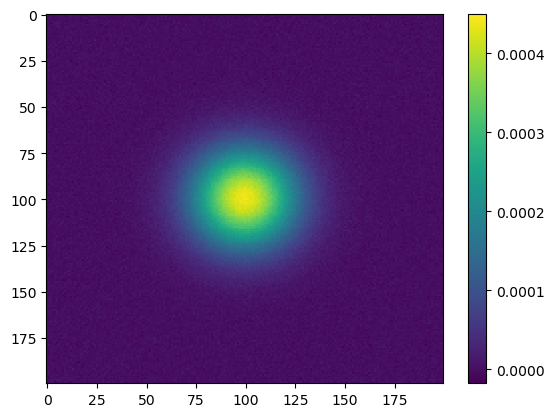

In [347]:
psf_box = (20,20)
oversampling = 10

psfcen_x = psfcen_y = 0

ys, xs = np.indices((psf_box[0]*oversampling, psf_box[1]*oversampling)).astype(float)
ys -= (ys.shape[0]-1)/2
xs -= (xs.shape[1]-1)/2

psf_x = (xs - psfcen_x)/oversampling
psf_y = (ys - psfcen_y)/oversampling

os_psf = np.exp(-0.5*(psf_x**2 + psf_y**2)/(1.9**2))

os_psf = os_psf + 0.01 * np.random.normal(size=os_psf.shape)

os_psf = os_psf / np.sum(os_psf)

plt.imshow(os_psf, aspect='auto', interpolation='nearest')
plt.colorbar()

And now make a spectral trace that's curvy

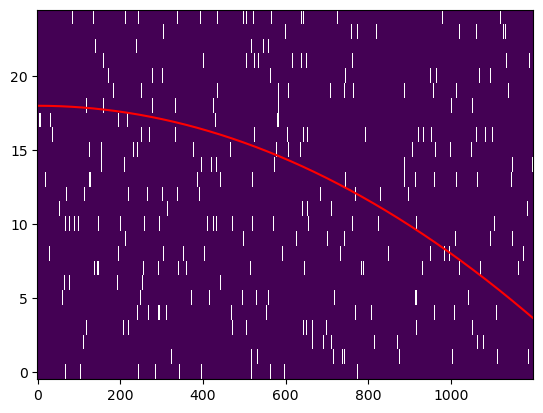

In [348]:
def tracefunc(x):
    return 18 - 10*(x/1000)**2

xtrace = np.arange(slit.shape[1])
ytrace = tracefunc(xtrace)

plt.imshow(slit,aspect='auto', interpolation='nearest', origin='lower')
plt.plot(xtrace, ytrace, color='red')

Note the biggest difference is that the real data have a lot more nans, but this smattering should be sufficient to catch relevant bugs.

In [349]:
xspec = np.arange(wave_m.size)/wave_m.size * slit.shape[1]
yspec = tracefunc(xspec)

# Algorithmic experimentation

In general we always take the grid to be the shape of the output pixels and hence can use the grid as a stand-in for the  slit shape.

In [350]:
maxpsf = max(np.max(psf_x), np.max(psf_y)).astype(np.float32).ravel()

@cuda.jit
def compute_influence(xspec, yspec, startidx, nspec):
    maxpsfc = cuda.const.array_like(maxpsf)  # not sure if this helps any but it at least shows that this  works

    x = cuda.blockIdx.x
    y = cuda.blockIdx.y

    idx = y * cuda.blockDim.x + x

    startidxi = -1
    count = 0
    for i, (xs, ys) in enumerate(zip(xspec, yspec)):
        if abs(x - xs) <= maxpsfc[0]:  #TODO: might need some buffer?
            if abs(y - ys) <= maxpsfc[0]:
                count += 1
                if startidxi == -1:
                    startidxi = i
    
    startidx[y, x] = startidxi
    nspec[y, x] = count
                

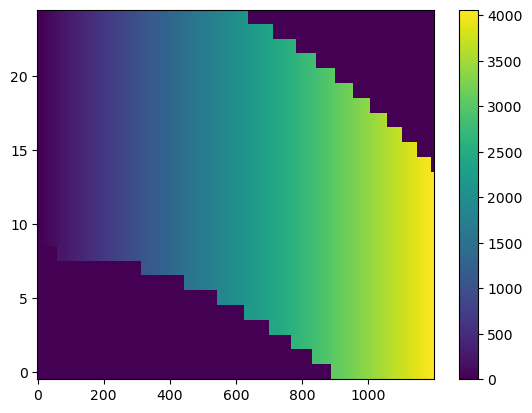

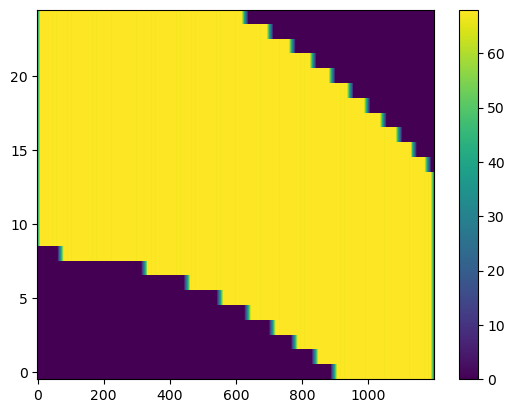

In [351]:
xspecc = cuda.to_device(xspec)
yspecc = cuda.to_device(yspec)
startidxc = cuda.device_array(slit.shape, dtype=np.int32)
nspecc = cuda.device_array(slit.shape, dtype=np.int32)

# one thread per block is wasteful but this is just a test.
compute_influence[slit.shape[::-1], 1](xspecc, yspecc, startidxc, nspecc)

plt.figure()
plt.imshow(startidxc, aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()

plt.figure()
plt.imshow(nspecc, aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()

Try having the blocks be over the influencing spec points

In [352]:
longest_stretch = int(cp.array(nspecc, copy=False).max())
longest_stretch32 = math.ceil(longest_stretch / 32) * 32
assert longest_stretch32 <= 1024, 'Only 1024 threads per block'
print(longest_stretch, longest_stretch32)

gridspec = slit.shape[::-1]
blockspec = longest_stretch32
kernelspec = (gridspec, blockspec)
kernelspec

68 96


((1200, 25), 96)

4109.37548828125

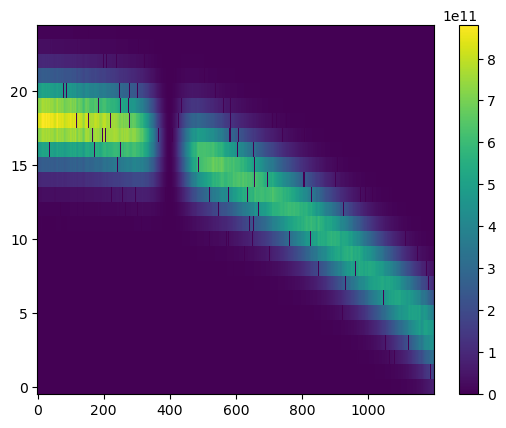

In [353]:
pixel_slope = -oversampling
pixel_intercept = (1+oversampling)/2

@cuda.jit(cache=True)
def scatter_flux(xspec, yspec, fluxspec,
                 psf_x, psf_y, psf_flux, 
                 startidx, nspec, 
                 outslit, testout):
    x = cuda.blockIdx.x
    y = cuda.blockIdx.y
    if math.isnan(outslit[y, x]):
        return

    tidx = cuda.threadIdx.x
    if tidx >= nspec[y, x]:
        return
    specidx = tidx + startidx[y, x]
    
    xsi = xspec[specidx]
    ysi = yspec[specidx]
    fsi = fluxspec[specidx]

    flux_contrib = 0.0
    for i in range(psf_x.shape[0]):
        for j in range(psf_x.shape[1]):
            xpi = xsi + psf_x[i, j] - x
            ypi = ysi + psf_y[i, j] - y

            ox = pixel_slope * abs(xpi) + pixel_intercept
            if ox > 1:
                ox = 1
            elif ox < 0:
                ox = 0 
            oy = pixel_slope * abs(ypi) + pixel_intercept
            if oy > 1:
                oy = 1
            elif oy < 0:
                oy = 0
 
            flux_contrib += ox*oy*fsi*psf_flux[i, j]
    outslit[y, x] = flux_contrib
    testout[y, x, tidx] = flux_contrib

fluxpecc = cuda.to_device(spectrum_fnu.astype(np.float32))

slitarr = -np.ones_like(slit)
slitarr[np.isnan(slit)] = np.nan
slitoutc = cuda.to_device(slitarr)

psf_xc = cuda.to_device(psf_x.astype(np.float32))
psf_yc = cuda.to_device(psf_y.astype(np.float32))
psf_flux = cuda.to_device(os_psf.astype(np.float32))

testout = cuda.device_array((slit.shape[0], slit.shape[1], kernelspec[-1]), dtype=np.float32)



# note this may need to be run twice due to the first time creating the disk cache.

start_evt = cuda.event(timing=True)
end_evt = cuda.event(timing=True)
start_evt.record() 
scatter_flux[kernelspec](xspecc, yspecc, fluxpecc, 
                         psf_xc, psf_yc, psf_flux,
                         startidxc, nspecc, 
                         slitoutc, testout)
end_evt.record()  
end_evt.synchronize() 

a = testout.copy_to_host()
plt.imshow(np.sum(a, axis=2), aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()

cuda.event_elapsed_time(start_evt, end_evt) #ms

Why is that so incredibly slow?

In [358]:
tflops = 30

datas = 200*200*longest_stretch32*slit.size/1024/1024/1024/1024 #Terra-ops

tflops/datas

286.3311530666667

that implies the inner loop requires 10k ops which is crazy pants.  Something must be wrong with access patterns. Switch to profiling?